# Bayesian Inference: Coin Flip with Importance Sampling

Demonstrate importance sampling via Metropolis: proposals from the **prior**, acceptance based on **likelihood ratio**.

This pattern is general and compatible with advanced algorithms (multicanonical, Wang-Landau, etc.).

In [1]:
using Pkg
Pkg.activate(dirname(@__DIR__))
Pkg.instantiate()

using Random
using Statistics
using Distributions
using Plots
using MonteCarloX

  Activating project at `~/.julia/dev/MonteCarloX.jl/examples`


## Setup: synthetic coin-flip data

- Observe 100 coin flips: 61 heads, 39 tails
- Prior: Beta(2, 2)
- Likelihood: θ^heads × (1-θ)^tails

In [2]:
# Data
n_heads, n_tails = 61, 39
α, β = 2.0, 2.0
prior = Beta(α, β)
posterior_exact = Beta(α + n_heads, β + n_tails)

logprior(θ) = logpdf(prior, θ)
loglikelihood(θ) = n_heads * log(θ) + n_tails * log1p(-θ)
logposterior(θ) = logprior(θ) + loglikelihood(θ)

println("Data: $(n_heads) heads, $(n_tails) tails")
println("Exact posterior: Beta($(α + n_heads), $(β + n_tails))")

Data: 61 heads, 39 tails
Exact posterior: Beta(63.0, 41.0)


## Local Metropolis-Hastings

- **Proposal:** small random-walk move around current $\theta$
- **Target:** log-posterior = log-prior + log-likelihood
- **Acceptance:** handled by `accept!` via posterior ratio

In [3]:
function run_metropolis_chain(logposterior, prior; seed=2026, Δ=0.03, n_steps=100_000, burn_in=10_000)
    rng = MersenneTwister(seed)
    alg = Metropolis(rng, logposterior)

    θ_current = rand(rng, prior)
    samples = Float64[]

    for step in 1:n_steps
        θ_new = θ_current + Δ * randn(rng)
        if 0.0 < θ_new < 1.0
            if accept!(alg, θ_new, θ_current)
                θ_current = θ_new
            end
        end
        step > burn_in && push!(samples, θ_current)
    end

    return samples, alg, Δ
end

samples, alg, Δ = run_metropolis_chain(logposterior, prior)

println("Δ: $(Δ)")
println("Acceptance rate: $(round(acceptance_rate(alg); digits=3))")
println("Samples collected: $(length(samples))")

Δ: 0.03
Acceptance rate: 0.808
Samples collected: 90000


## Results

Posterior mean (MCMC): 0.6049
Posterior mean (exact): 0.6058
95% CI (MCMC):  [0.5091, 0.696]
95% CI (exact): [0.5106, 0.6971]


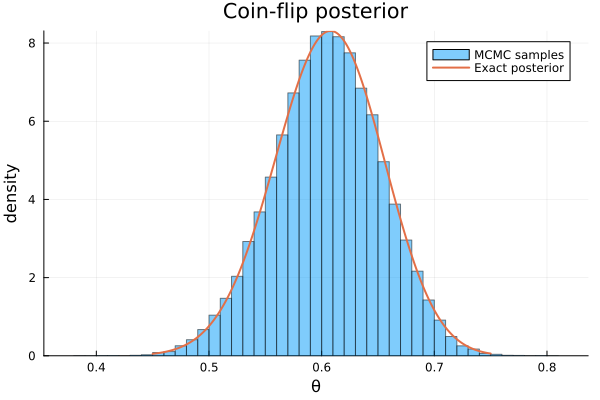

In [4]:
mean_mcmc = mean(samples)
mean_exact = mean(posterior_exact)
ci_mcmc = quantile(samples, [0.025, 0.975])
ci_exact = quantile(posterior_exact, [0.025, 0.975])

println("Posterior mean (MCMC): $(round(mean_mcmc; digits=4))")
println("Posterior mean (exact): $(round(mean_exact; digits=4))")
println("95% CI (MCMC):  [$(round(ci_mcmc[1]; digits=4)), $(round(ci_mcmc[2]; digits=4))]")
println("95% CI (exact): [$(round(ci_exact[1]; digits=4)), $(round(ci_exact[2]; digits=4))]")

xgrid = range(0.45, 0.75, length=300)
p = histogram(samples; bins=50, normalize=:pdf, alpha=0.5, label="MCMC samples", xlabel="θ", ylabel="density")
plot!(p, xgrid, pdf.(posterior_exact, xgrid); lw=2, label="Exact posterior", title="Coin-flip posterior")